In [4]:
import mujoco
from pathlib import Path

robot_path = Path('my-robot/robot.urdf')
asset_dir = (robot_path.parent / 'assets').resolve()

# MuJoCo does not resolve the URDF's `package://assets/...` references
# correctly for this file layout, so rewrite them to absolute paths.
urdf_xml = robot_path.read_text().replace(
    'package://assets/',
    f'{asset_dir.as_posix()}/'
)

model = mujoco.MjModel.from_xml_string(urdf_xml)
print(model.nmesh, model.ngeom)


5 5


Matplotlib is building the font cache; this may take a moment.


""

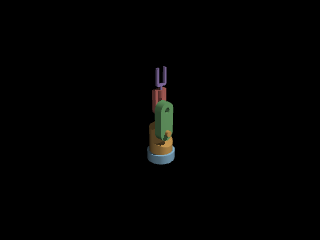

In [6]:
import mujoco
import mediapy as media
from pathlib import Path

xml_path = Path("my-robot/my_robot.xml")
asset_dir = Path("my-robot/assets")
xml = xml_path.read_text()
assets = {f"assets/{path.name}": path.read_bytes() for path in asset_dir.glob("*.stl")}

model = mujoco.MjModel.from_xml_string(xml, assets=assets)
data = mujoco.MjData(model)
mujoco.mj_forward(model, data)

camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 1.2
camera.azimuth = 45
camera.elevation = -25
camera.lookat[:] = model.stat.center

renderer = mujoco.Renderer(model)
renderer.update_scene(data, camera=camera)
media.show_image(renderer.render())
renderer.close()
